# Plotting Tutorial with `metaheuristic‑designer`

This notebook demonstrates the plotting ideas from the documentation using
**Differential Evolution** on the **Rastrigin** function.  We’ll record best,
median, worst, full objective vectors, diversity, and scheduled parameters,
then create a variety of plots.

All plots use `pandas`, `seaborn` and `matplotlib`.  Install them with
`pip install pandas seaborn matplotlib` if needed.

In [128]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import metaheuristic_designer as mhd
from metaheuristic_designer.benchmarks import Rastrigin
from metaheuristic_designer.initializers import UniformInitializer
from metaheuristic_designer.operators import create_operator
from metaheuristic_designer.strategies import DE
from metaheuristic_designer.algorithms import Algorithm
from metaheuristic_designer.history_tracker import HistoryTracker
from metaheuristic_designer.stopping_condition import StoppingCondition
from metaheuristic_designer.reporters.tqdm_reporter import TQDMReporter
from metaheuristic_designer.parameter_schedules import LinearSchedule

In [129]:
sns.set_theme(style="whitegrid")
rng = mhd.check_random_state(42)

## 1. Define the problem
We'll minimize the 5‑dimensional Rastrigin function.

In [130]:
DIM = 5
objfunc = Rastrigin(DIM, mode="min")

## 2. Build a DE strategy with a scheduled parameter
We use `DE/rand/1/bin` with population size 100. The scale factor *F* will
decay linearly from 0.8 to 0.1 over the course of the run.  The crossover rate
*Cr* is kept constant.  The schedule object is passed directly as the `F`
argument – the framework evaluates it at each generation using the current
progress.

In [131]:
strategy = DE(
    initializer=UniformInitializer(
        objfunc.vecsize, objfunc.lower_bound, objfunc.upper_bound,
        pop_size=100, random_state=rng
    ),
    de_operator_name="DE/rand/1",
    F=LinearSchedule(init_value=0.8, final_value=0.1),
    Cr=0.9,
    random_state=rng,
)

## 3. Configure the History Tracker
We enable several tracking flags:
- **best** (always on)
- **median** and **worst** to show spread
- **full_objective** to create boxplots of the fitness distribution
- **diversity** to monitor population diversity
- **parameters** to record the evolution of scheduled parameters like `F`

In [132]:
history = HistoryTracker(
    track_median=True,
    track_worst=True,
    track_full_objective=True,
    track_diversity=True,
    track_parameters=True,
)

## 4. Create and run the algorithm
We use `max_iterations=200` as the stopping condition and a `TQDMReporter`
for a progress bar.

In [133]:
from metaheuristic_designer.reporters import SilentReporter


stop = StoppingCondition(
    condition_str="max_iterations",
    max_iterations=200,
    optimization_mode=objfunc.mode,
)

algo = Algorithm(
    objfunc,
    strategy,
    stopping_condition=stop,
    # reporter=TQDMReporter(),
    reporter=SilentReporter(),
    history_tracker=history,
)

population = algo.optimize()

## 5. Retrieve the recorded data
`to_pandas()` returns a DataFrame with iteration, best/median/worst objective,
diversity, and scheduled parameter columns.  `to_pandas_full_objective()` returns
a wide‑format DataFrame with one column per individual showing their objective
at every generation.

In [134]:
df = algo.history_tracker.to_pandas()
full_obj_df = algo.history_tracker.to_pandas_full_objective()

print("Columns in df:", list(df.columns))
print("\nFull objective DataFrame (first 3 rows):")
display(full_obj_df.head(3))

Columns in df: ['iteration', 'best_objective', 'median_objective', 'worst_objective', 'diversity', 'Nothing.amount', 'DE/rand/1.F', 'DE/rand/1.Cr', 'DE/rand/1.p']

Full objective DataFrame (first 3 rows):


,iteration,Individual_0,Individual_1,Individual_2,Individual_3,Individual_4,Individual_5,Individual_6,Individual_7,Individual_8,...,Individual_90,Individual_91,Individual_92,Individual_93,Individual_94,Individual_95,Individual_96,Individual_97,Individual_98,Individual_99
0,0,85.928828,99.328019,117.585893,119.479019,102.945625,103.551785,98.221814,76.390326,85.895166,...,110.918787,94.498455,92.916896,99.569645,69.957496,41.774544,53.9167,56.93063,64.613442,72.063343
1,1,83.249375,92.681725,76.299933,72.074400,74.338878,103.551785,70.052872,76.390326,85.895166,...,110.918787,94.498455,92.916896,99.569645,69.957496,41.774544,53.9167,56.93063,64.613442,72.063343
2,2,83.249375,92.681725,76.299933,72.074400,74.338878,52.360732,70.052872,76.390326,85.895166,...,88.479790,94.498455,70.306399,75.818858,69.957496,41.774544,53.9167,56.93063,64.613442,62.220852


## 6. Convergence of best, median and worst
We plot the three curves together and shade the range between best and worst.

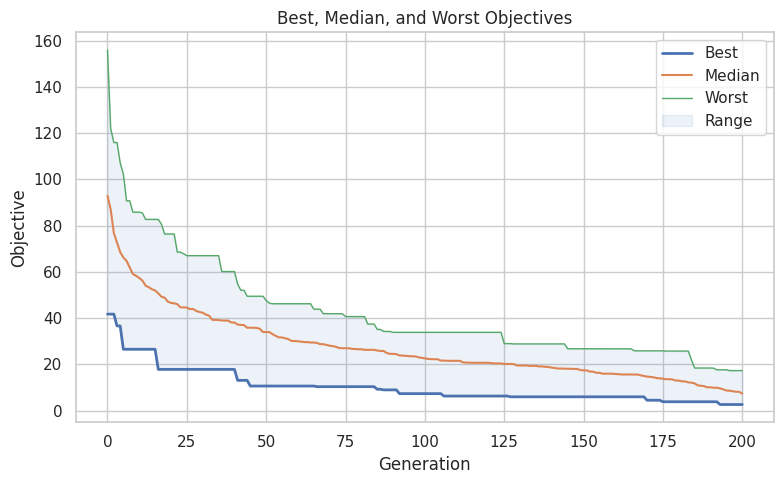

In [135]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.lineplot(data=df, x="iteration", y="best_objective", label="Best", linewidth=2, ax=ax)
sns.lineplot(data=df, x="iteration", y="median_objective", label="Median", linewidth=1.5, ax=ax)
sns.lineplot(data=df, x="iteration", y="worst_objective", label="Worst", linewidth=1, ax=ax)
ax.fill_between(df["iteration"], df["worst_objective"], df["best_objective"],
                alpha=0.1, color="steelblue", label="Range")
ax.set_xlabel("Generation")
ax.set_ylabel("Objective")
ax.set_title("Best, Median, and Worst Objectives")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Fitness distribution across generations
We melt the wide‑format full objective DataFrame into long format and create
a boxplot every 10 generations.  This reveals how the population converges
over time.

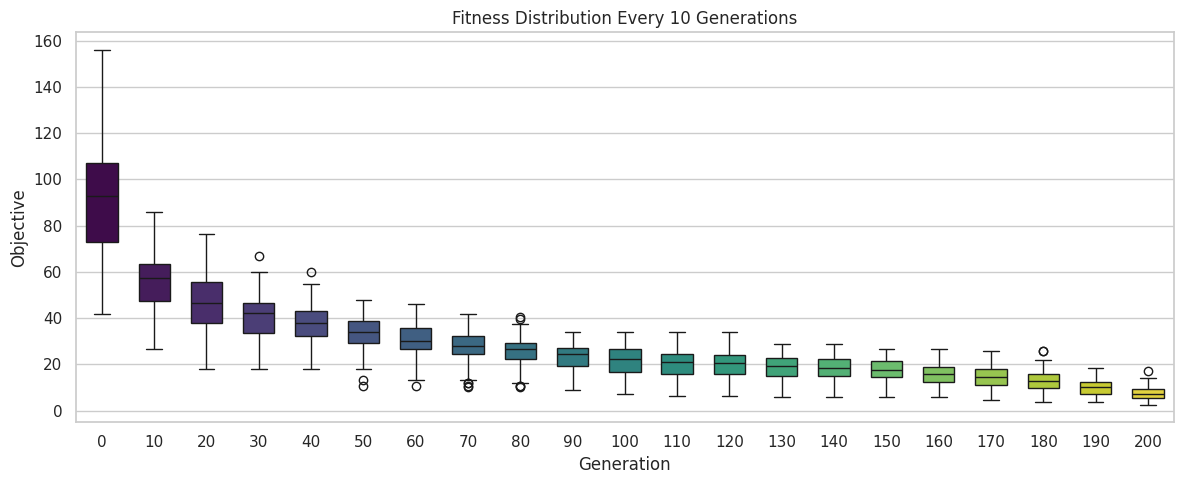

In [136]:
long_df = full_obj_df.melt(id_vars="iteration", var_name="individual", value_name="objective")
# Keep every 10th generation to avoid overplotting
plot_data = long_df[long_df["iteration"] % 10 == 0]

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=plot_data, x="iteration", y="objective", hue="iteration", ax=ax,
            palette="viridis", width=0.6, legend=False)
ax.set_xlabel("Generation")
ax.set_ylabel("Objective")
ax.set_title("Fitness Distribution Every 10 Generations")
plt.tight_layout()
plt.show()

## 8. Diversity evolution
The `diversity` column tracks the average Euclidean distance of the genotypes
from their centroid.  We plot it alongside the best objective on a dual‑axis
plot.

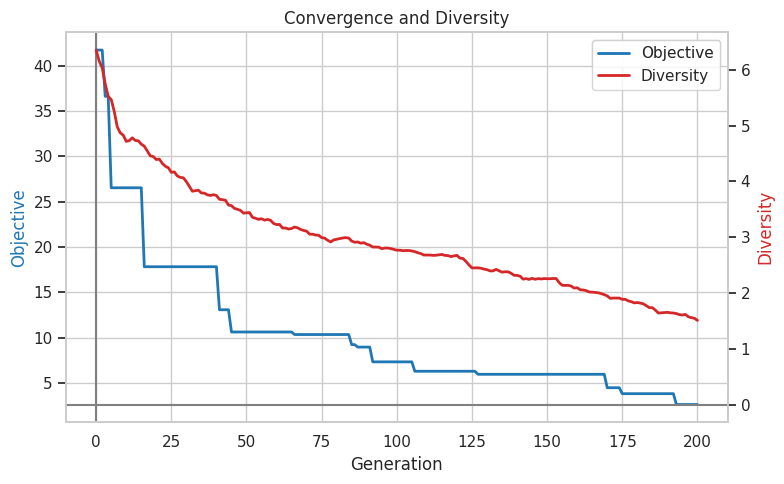

In [137]:
fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx()

sns.lineplot(data=df, x="iteration", y="best_objective", ax=ax1,
             linewidth=2, color="tab:blue", label="Objective", zorder=100)
sns.lineplot(data=df, x="iteration", y="diversity", ax=ax2,
             linewidth=2, color="tab:red", label="Diversity", zorder=100)

ax1.set_xlabel("Generation")
ax1.set_ylabel("Objective", color="tab:blue")
ax2.set_ylabel("Diversity", color="tab:red")
ax1.set_title("Convergence and Diversity")
ax2.grid(False)

ax1.axvline(0, color="gray")
ax2.axhline(0, color="gray")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
plt.tight_layout()
plt.show()

## 9. Scheduled parameter evolution
When `track_parameters=True`, the tracker records the current value of every
scheduled parameter.  The column names follow the pattern
`component_name.parameter`, e.g. `mutation.gaussian_mutation.F`.
Since our DE strategy stores the `F` parameter on its internal operator, we can
inspect the column names and plot them.

Scheduled parameter columns: ['Nothing.amount', 'DE/rand/1.F', 'DE/rand/1.Cr', 'DE/rand/1.p']


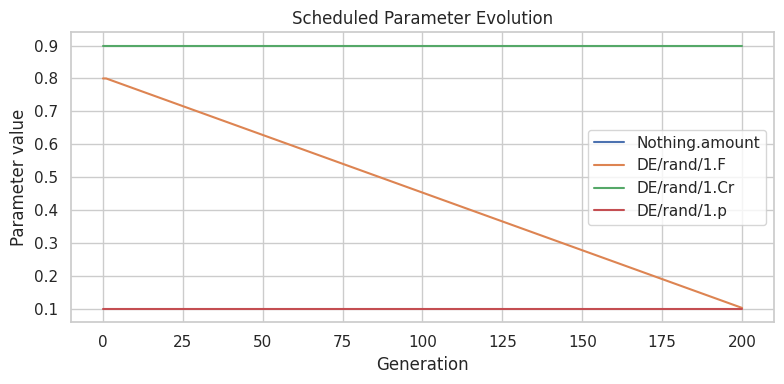

In [138]:
# Identify which columns are parameters (all except those we know)
metric_cols = ["iteration", "best_objective", "median_objective", "worst_objective", "diversity"]
param_cols = [col for col in df.columns if col not in metric_cols]

print("Scheduled parameter columns:", param_cols)

if param_cols:
    fig, ax = plt.subplots(figsize=(8, 4))
    for col in param_cols:
        sns.lineplot(data=df, x="iteration", y=col, ax=ax, label=col)
    ax.set_xlabel("Generation")
    ax.set_ylabel("Parameter value")
    ax.set_title("Scheduled Parameter Evolution")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 10. Dashboard: combining several views
We put convergence, fitness distribution, and diversity into a single figure.

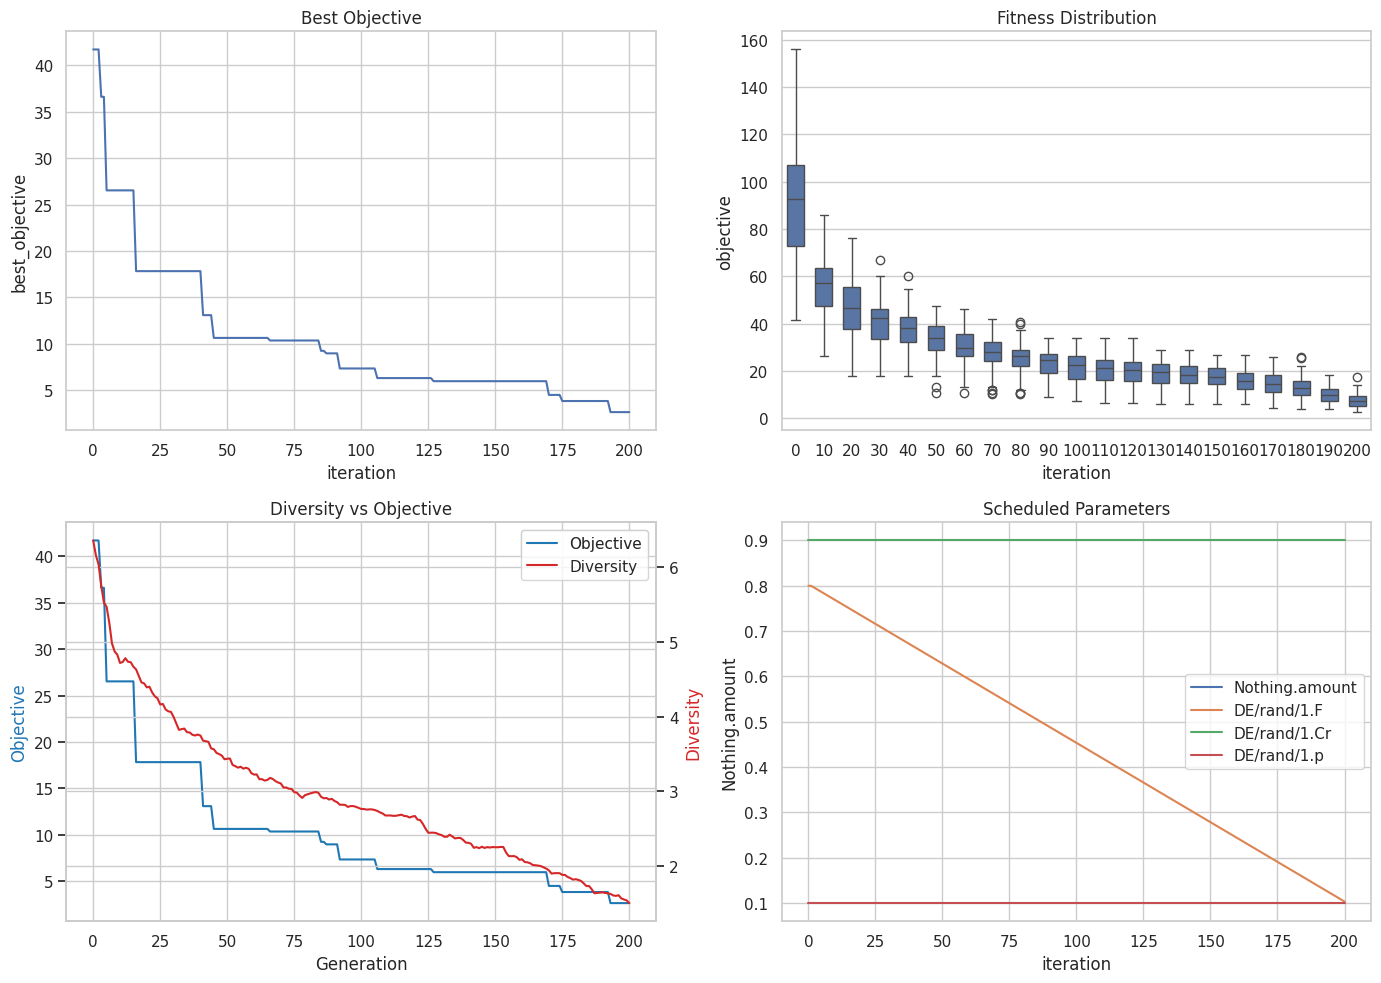

In [139]:
fig = plt.figure(figsize=(14, 10))

# Convergence
ax1 = fig.add_subplot(2, 2, 1)
sns.lineplot(data=df, x="iteration", y="best_objective", ax=ax1)
ax1.set_title("Best Objective")

# Fitness distribution (every 10th generation)
ax2 = fig.add_subplot(2, 2, 2)
plot_data = long_df[long_df["iteration"] % 10 == 0]
sns.boxplot(data=plot_data, x="iteration", y="objective", ax=ax2, width=0.6)
ax2.set_title("Fitness Distribution")

# Diversity
ax3 = fig.add_subplot(2, 2, 3)
ax3_twin = ax3.twinx()
sns.lineplot(data=df, x="iteration", y="diversity", ax=ax3_twin, color="tab:red", label="Diversity")
sns.lineplot(data=df, x="iteration", y="best_objective", ax=ax3, color="tab:blue", label="Objective")
ax3.set_title("Diversity vs Objective")
ax3.set_xlabel("Generation")
ax3.set_ylabel("Objective", color="tab:blue")
ax3_twin.set_ylabel("Diversity", color="tab:red")
# Merge legends
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3_twin.get_legend_handles_labels()
ax3_twin.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

# Parameter(s) if present
ax4 = fig.add_subplot(2, 2, 4)
if param_cols:
    for col in param_cols:
        sns.lineplot(data=df, x="iteration", y=col, ax=ax4, label=col)
    ax4.set_title("Scheduled Parameters")
    ax4.legend()
else:
    ax4.text(0.5, 0.5, "No parameters recorded", ha="center", va="center")
    ax4.set_title("Scheduled Parameters (none)")

plt.tight_layout()
plt.show()

## 11. Final result
Print the best solution found and its objective value.

In [140]:
solution, objective = algo.best_solution()
print(f"Best objective: {objective:.6f}")
print("Best solution:", solution)

Best objective: 2.619549
Best solution: [ 0.99495766  0.97049337  0.04793877  0.00660641 -0.01591332]
